# Q-bonus — QLoRA Fine-tune of Llama-3.2-3B on 20 Newsgroups

**HSLU NALAPRO project — Bonus question.** _Author: Dan Waititu (`danwwaititu@gmail.com`)._

## Research question

> _"Fine-tune Llama-3 (using LoRA or QLoRA) on the 20 Newsgroups classification task, evaluate the results, and compare to the other methods — including the Q4 zero-shot and few-shot baselines."_ — bonus addendum to `project_description/NALAPRO Project.pdf`.

Q4 froze Llama-3 entirely and prompted it. This notebook keeps the same Llama-3.2-3B weights but **trains a thin LoRA adapter** on top of a 4-bit-quantized backbone ("QLoRA"; Dettmers et al., 2023). Adding only ~ 0.2 % of new trainable parameters and training for a few epochs on the 20 NG train split should outperform Q4 by a wide margin and let us measure the gap to the supervised BERT (Q2) and MLM-then-fine-tune (Q3) baselines.

## Self-contained

This notebook does **not** import from the `nlp_project` package — every helper it needs is defined inline below (sections 3–4). It runs unchanged on Google Colab (A100 high-RAM strongly recommended) without cloning the repo, and on a local CUDA box with the runtime deps installed.

## Runs performed

| Run name | LoRA rank | lr | Epochs | Effective batch | Purpose |
|---|---:|---:|---:|---:|---|
| `qbonus-qlora-r16-lr2e4` | 16 | 2e-4 | 3 | 32 | Baseline QLoRA config. |
| `qbonus-qlora-r32-lr1e4` | 32 | 1e-4 | 3 | 32 | Higher rank, lower LR — sweep for best accuracy. |

The notebook picks the **best run by held-out val macro-F1** and uses that adapter for the final test-set evaluations.

## Evaluation strategy

Two final-eval passes on the picked adapter:

1. **Full 20 NG test set (7 532 docs)** → comparable to Q1 (MLP), Q2 (BERT fine-tune), Q3 (MLM-then-fine-tune).
2. **Q4 stratified 200-doc subset (seed 42, 10 per class)** → comparable to Q4 zero/few-shot.

Both subsets are built deterministically with the same seed as the rest of the project, so cross-experiment comparisons are exact.

## Model and hardware

- **Model**: `meta-llama/Llama-3.2-3B-Instruct` (same checkpoint as Q4).
- **Quantization**: 4-bit nf4 with double quantization, bf16 compute (`bitsandbytes`).
- **Adapter**: LoRA on the four attention projections `{q,k,v,o}_proj`; classification head (`score`) trained in full precision via PEFT `modules_to_save`.
- **Training**: HuggingFace `Trainer`, bf16, cosine LR schedule, 3 % warmup.
- **Hardware**: Colab A100 40 GB (target). Also runs on a 24 GB Ampere card (RTX 3090 / 4090).

## Deliverables produced by this notebook

- `models/qbonus_results/qbonus_qlora_full_test.json` — metrics on the full 7 532-doc test set.
- `models/qbonus_results/qbonus_qlora_q4subset.json` — metrics on the Q4 200-doc subset.
- `models/qbonus_results/qbonus_sweep_summary.json` — best val macro-F1 per LoRA config.
- `figures/qbonus_confusion_full.png` — confusion matrix on the full test set.
- `figures/qbonus_comparison_bars.png` — accuracy / macro-F1 across all available methods (Q4 zero/few-shot, Q2, Q3 if present, plus this notebook on both eval splits).
- `figures/qbonus_per_class_delta.png` — per-class F1 lift vs Q4 zero-shot.

## W&B runs

Project `hslu-nalapro`, group `qbonus`. Paste the run URLs below once executed:

- <https://wandb.ai/danwwaititu-hochschule-luzern/hslu-nalapro?nw=nwuserdanwwaititu> _(group `qbonus`)_

## AI tool disclosure

Per spec §7, this notebook (cells + markdown) was co-authored with **Claude Code** (Anthropic, model `claude-opus-4-7`). The design choices (QLoRA over full fine-tune, sequence-classification head over generative SFT, sweep dimensions, eval-on-both-splits strategy) reflect the author's judgement; numerical results are reproduced from single executions with `SEED = 42` throughout.

## 1. Environment setup — Colab A100 vs local CUDA

This notebook runs unchanged on two hosts:

1. **Google Colab (A100 high-RAM)** — open the notebook, run the cell below; it pip-installs the runtime deps and prompts for HuggingFace + W&B logins. Llama-3.2 is gated, so request access on the model page first (`huggingface.co/meta-llama/Llama-3.2-3B-Instruct`).
2. **Local CUDA (24 GB+ Ampere)** — `pip install transformers accelerate bitsandbytes peft wandb scikit-learn seaborn pandas tqdm`; `wandb login`; `huggingface-cli login`.

**No repo clone, no `pip install -e .`.** Every helper this notebook uses is defined inline in sections 3–4.

In [1]:
# --- detect environment ---------------------------------------------------
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f'IN_COLAB = {IN_COLAB}')

if IN_COLAB:
    import subprocess, sys
    # Pin upper bounds loose; Colab's pre-installed torch is kept (do NOT reinstall it).
    subprocess.check_call([sys.executable, '-m', 'pip', '-q', 'install',
        'transformers>=4.45', 'accelerate>=0.34', 'bitsandbytes>=0.43',
        'peft>=0.13', 'wandb', 'scikit-learn', 'seaborn', 'pandas', 'tqdm'])
    from huggingface_hub import notebook_login as hf_login
    hf_login()
    import wandb
    wandb.login()

# --- device sanity check --------------------------------------------------
import torch
if torch.cuda.is_available():
    print(f'CUDA OK \u2014 device 0 = {torch.cuda.get_device_name(0)}')
    free, total = torch.cuda.mem_get_info()
    print(f'free / total VRAM = {free / 1e9:.2f} / {total / 1e9:.2f} GB')
else:
    raise RuntimeError(
        'No CUDA detected. QLoRA training of a 3B model on CPU/MPS is infeasible \u2014 '
        'open this notebook on a CUDA host (A100 recommended).'
    )


IN_COLAB = True


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: danwwaititu (danwwaititu-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


CUDA OK — device 0 = NVIDIA A100-SXM4-40GB
free / total VRAM = 41.96 / 42.41 GB


## 2. Imports, seed, output directories

Standard scientific stack plus `transformers`, `peft`, `bitsandbytes`, `wandb`, `sklearn`. We define `SEED = 42` and `set_seed` inline so the notebook is self-contained.

**Why seed everything:** Two reasons in this notebook. (i) The stratified val/test subsamples must match Q1–Q4 byte-for-byte for the cross-question comparison to be valid. (ii) LoRA's `score` head is freshly initialised; reproducible initialisation lets us compare two LoRA configs on equal footing instead of conflating config differences with init noise.

In [2]:
import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import wandb
from sklearn.model_selection import train_test_split

SEED = 42

def set_seed(seed: int = SEED) -> None:
    """Seed Python, NumPy, env-hash, and PyTorch (CPU + CUDA) from one constant."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

# Outputs land relative to the notebook's working directory. On Colab that's /content/.
RESULTS_DIR = Path('models/qbonus_results'); RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = Path('figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR = Path('models/qbonus_ckpt'); CKPT_DIR.mkdir(parents=True, exist_ok=True)
# Optional comparison data; only used if present locally:
Q4_DIR = Path('models/q4_results')
Q2_BASELINE = Path('models/q2_results/q2b_baseline.json')
Q3_BASELINE = Path('models/q3_results/q3_finetune_results.json')

MODEL_NAME = 'meta-llama/Llama-3.2-3B-Instruct'
MAX_LENGTH = 512  # ~95% of 20NG docs fit; longer would slow training quadratically.

print('results ->', RESULTS_DIR.resolve())
print('figures ->', FIG_DIR.resolve())
print('ckpts   ->', CKPT_DIR.resolve())


results -> /content/models/qbonus_results
figures -> /content/figures
ckpts   -> /content/models/qbonus_ckpt


## 3. Inline helpers — data, metrics, plotting

Four small utilities, defined here so the notebook does not depend on the `nlp_project` package:

- **`load_20ng(remove=True)`** — fetch 20 Newsgroups train/test splits from sklearn. `remove=True` strips headers/footers/quoted text (spec §3, label-leakage rule).
- **`train_val_split(docs, labels, val_frac=0.1, seed=42)`** — stratified 90/10 carve of the training set; uses `random_state=42` so the val indices are **byte-identical to Q1/Q2/Q3**.
- **`metrics_from_predictions(y_true, y_pred, label_names)`** — accuracy + macro-F1 + per-class F1 + confusion matrix, returned as a dict.
- **`plot_confusion(cm, label_names, save_path, title)`** — seaborn heatmap saved as PNG.

In [3]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import accuracy_score, confusion_matrix as _cm, f1_score

def load_20ng(remove: bool = True):
    """Fetch 20 Newsgroups. Returns (train_docs, train_labels, test_docs, test_labels, label_names).

    `remove=True` strips headers/footers/quoted text (spec \u00a73, avoid label leakage).
    """
    remove_tuple = ('headers', 'footers', 'quotes') if remove else ()
    tr = fetch_20newsgroups(subset='train', remove=remove_tuple)
    te = fetch_20newsgroups(subset='test',  remove=remove_tuple)
    return list(tr.data), np.asarray(tr.target), list(te.data), np.asarray(te.target), list(tr.target_names)

def train_val_split(docs, labels, val_frac: float = 0.1, seed: int = SEED):
    """Stratified 90/10 carve, seed-pinned for Q1\u2194Q-bonus val-index parity."""
    tr_d, va_d, tr_y, va_y = train_test_split(
        list(docs), np.asarray(labels),
        test_size=val_frac, stratify=labels, random_state=seed,
    )
    return tr_d, np.asarray(tr_y), va_d, np.asarray(va_y)

def metrics_from_predictions(y_true, y_pred, label_names):
    """Standard classification metrics from already-computed predictions."""
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    labels = list(range(len(label_names)))
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'per_class_f1': f1_score(y_true, y_pred, average=None, labels=labels, zero_division=0),
        'confusion_matrix': _cm(y_true, y_pred, labels=labels),
    }

def plot_confusion(cm, label_names, save_path, title='Confusion matrix'):
    """Seaborn heatmap of a confusion matrix, saved as PNG."""
    fig, ax = plt.subplots(figsize=(0.5 * len(label_names) + 2, 0.5 * len(label_names) + 2))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, cbar=False, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    fig.tight_layout(); fig.savefig(save_path, dpi=150); plt.close(fig)
    print('Saved figure ->', save_path)


## 4. Inline helpers — tokenization & dataset wrapper

We need a `torch.utils.data.Dataset` that yields `{input_ids, attention_mask, labels}` for HuggingFace `Trainer`. Two design choices:

- **Pad dynamically** via `DataCollatorWithPadding` rather than padding to a fixed length at tokenization time. Saves ~ 30 % of compute on a corpus with high variance in document length (which 20 NG has — many one-line posts mixed with 1 k-token threads).
- **`padding_side='right'`** on the Llama tokenizer (default) is fine for training: `LlamaForSequenceClassification` uses the **last non-padding token** for pooling, located via the attention mask. Left-padding is only required for *generative* inference at batch size > 1, which is not how the Trainer runs classification.

**Llama lacks a pad token.** We point `tokenizer.pad_token` at `eos_token` and **also** set `model.config.pad_token_id` to that ID. Forgetting the second line makes `LlamaForSequenceClassification` warn and (in some transformers versions) pool on the wrong token \u2014 silently degrading accuracy.

In [4]:
class NewsgroupsDataset(torch.utils.data.Dataset):
    """Light wrapper around tokenized inputs + integer labels.

    Inputs are pre-tokenized once (no padding); the Trainer's data collator pads each
    batch dynamically. Labels are kept as Python ints; the collator converts them to a tensor.
    """
    def __init__(self, encodings, labels):
        self.input_ids = encodings['input_ids']
        self.attention_mask = encodings['attention_mask']
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels': int(self.labels[idx]),
        }

def tokenize_docs(tokenizer, docs, max_length: int = MAX_LENGTH):
    """Tokenize a list of strings without padding (collator will pad per batch)."""
    return tokenizer(
        list(docs),
        truncation=True,
        max_length=max_length,
        padding=False,
        return_attention_mask=True,
    )


## 5. Data \u2014 20 Newsgroups train / val / test + Q4 200-doc subset

**Splits:**

- Train: 90 % of 20 NG train (\u224810 182 docs after stratified carve).
- Val: 10 % of 20 NG train (\u22481 132 docs). Same indices as Q1/Q2/Q3 thanks to `seed=42`.
- Test (full): all 7 532 docs of 20 NG test \u2014 the headline number that compares vs Q1/Q2/Q3.
- Test (Q4 subset): 200-doc stratified subset of the test set, **identical** seed 42 carve as the Q4 notebook \u2014 the number that compares vs Q4 zero/few-shot.

Both test sets are byte-identical to other questions; subsampling for the Q4 subset uses `train_test_split(test_size=200, stratify=test_labels, random_state=42)` exactly as Q4 does.

In [5]:
train_all_docs, train_all_labels, test_docs, test_labels, label_names = load_20ng(remove=True)
tr_docs, tr_y, va_docs, va_y = train_val_split(train_all_docs, train_all_labels, val_frac=0.1, seed=SEED)

print(f'train  : {len(tr_docs):>6d} docs')
print(f'val    : {len(va_docs):>6d} docs')
print(f'test   : {len(test_docs):>6d} docs (full)')
print(f'classes: {len(label_names):>6d}')

# Q4 200-doc stratified subset (10/class, seed 42) \u2014 same call as the Q4 notebook.
_, q4_eval_docs, _, q4_eval_labels = train_test_split(
    test_docs, test_labels,
    train_size=len(test_docs) - 200,
    test_size=200,
    stratify=test_labels,
    random_state=SEED,
)
q4_eval_docs = list(q4_eval_docs)
q4_eval_labels = np.asarray(q4_eval_labels)
print(f'q4 subset: {len(q4_eval_docs)} docs (matches Q4 zero/few-shot eval set)')


train  :  10182 docs
val    :   1132 docs
test   :   7532 docs (full)
classes:     20
q4 subset: 200 docs (matches Q4 zero/few-shot eval set)


## 6. Tokenizer and tokenized datasets

Load the Llama-3 tokenizer (gated; needs `huggingface-cli login` first). Build `NewsgroupsDataset` objects for train, val, full-test, and Q4-subset.

**Quick token-length sanity check:** print the 50/95/99-percentile of pre-truncation token lengths on the *train* split, so we can see how many docs `MAX_LENGTH = 512` is actually cutting off.

In [6]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token
    print(f'set tokenizer.pad_token = eos ({tokenizer.eos_token!r}, id={tokenizer.pad_token_id})')

# Token-length sanity \u2014 measured on a random 1 000-doc sample (full corpus would be slow).
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(tr_docs), size=min(1000, len(tr_docs)), replace=False)
sample_lens = [len(tokenizer(tr_docs[i], add_special_tokens=True)['input_ids']) for i in sample_idx]
p50, p95, p99 = np.percentile(sample_lens, [50, 95, 99])
print(f'token-length p50/p95/p99 = {p50:.0f} / {p95:.0f} / {p99:.0f}')
print(f'fraction truncated at MAX_LENGTH={MAX_LENGTH}: {np.mean(np.asarray(sample_lens) > MAX_LENGTH):.3f}')

# Tokenize every split. Train tokenization is the slow one (\u224830 s on Colab).
tr_enc      = tokenize_docs(tokenizer, tr_docs,      MAX_LENGTH)
va_enc      = tokenize_docs(tokenizer, va_docs,      MAX_LENGTH)
te_enc      = tokenize_docs(tokenizer, test_docs,    MAX_LENGTH)
q4_enc      = tokenize_docs(tokenizer, q4_eval_docs, MAX_LENGTH)

tr_ds = NewsgroupsDataset(tr_enc, tr_y)
va_ds = NewsgroupsDataset(va_enc, va_y)
te_ds = NewsgroupsDataset(te_enc, test_labels)
q4_ds = NewsgroupsDataset(q4_enc, q4_eval_labels)
print(f'datasets: train={len(tr_ds)}, val={len(va_ds)}, test(full)={len(te_ds)}, test(q4)={len(q4_ds)}')


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

set tokenizer.pad_token = eos ('<|eot_id|>', id=128009)
token-length p50/p95/p99 = 122 / 813 / 2393
fraction truncated at MAX_LENGTH=512: 0.086
datasets: train=10182, val=1132, test(full)=7532, test(q4)=200


## 7. The QLoRA training helper

Encapsulates one LoRA run: load fresh 4-bit base \u2192 wrap with LoRA \u2192 train via HuggingFace `Trainer` \u2192 save best adapter \u2192 return val macro-F1 and adapter path. Two reasons to factor this out instead of inlining in cells 8 / 9:

1. **Memory hygiene.** Each run reloads the base 4-bit model so we never have two PEFT wrappers in memory at once. On A100 this is essentially free (~ 2 s).
2. **Clean sweeps.** Both runs share identical Trainer wiring; only the LoRA config and learning rate differ. Centralising the wiring makes the difference explicit.

**Key configuration choices:**

- `BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type='nf4', bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)` \u2014 the canonical QLoRA setup.
- `prepare_model_for_kbit_training(model)` \u2014 disables grad-cache caching and enables gradient checkpointing-friendly hooks; required before adding LoRA layers to a quantized model.
- `LoraConfig(task_type='SEQ_CLS', target_modules=['q_proj','k_proj','v_proj','o_proj'], modules_to_save=['score'])` \u2014 LoRA on the four attention projections (standard), and the freshly-initialised classification head trained in full precision (essential: see (i) below).
- `bf16=True` (A100 native), `gradient_checkpointing=True` (cuts activation memory), `gradient_accumulation_steps=4` (effective batch 32 with per-device batch 8).
- `metric_for_best_model='eval_macro_f1'`, `load_best_model_at_end=True` \u2014 the best epoch's adapter is what survives; intermediate epochs are pruned by `save_total_limit=2`.

**(i) Why `modules_to_save=['score']` is essential.** `LlamaForSequenceClassification` initialises a fresh `nn.Linear(hidden_size, num_labels)` head (no pretrained weights at all for `num_labels = 20`). If we only attached LoRA, the head would stay at its random init forever \u2014 the LoRA layers can't compose into the *base* head's weights. `modules_to_save` tells PEFT to fully train this module in addition to the LoRA adapters.

In [7]:
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training
from transformers import (
    BitsAndBytesConfig,
    DataCollatorWithPadding,
    LlamaForSequenceClassification,
    Trainer,
    TrainingArguments,
)

BNB_CONFIG = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

def _load_quantized_base():
    """Fresh 4-bit Llama with a 20-way classification head.

    Note: `LlamaForSequenceClassification.from_pretrained(..., num_labels=20)` initialises
    the score head from scratch, so each call returns a model with a *different* random
    head unless we re-seed. `set_seed()` is called before each invocation in `run_lora`.
    """
    model = LlamaForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(label_names),
        quantization_config=BNB_CONFIG,
        device_map='auto',
    )
    model.config.pad_token_id = tokenizer.pad_token_id
    return model

def _compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.asarray(logits).argmax(axis=-1)
    m = metrics_from_predictions(labels, preds, label_names)
    return {'accuracy': float(m['accuracy']), 'macro_f1': float(m['macro_f1'])}

def run_lora(
    run_name: str,
    *,
    lora_r: int,
    lora_alpha: int,
    learning_rate: float,
    num_train_epochs: int = 3,
    per_device_batch_size: int = 8,
    grad_accum: int = 4,
    lora_dropout: float = 0.05,
):
    """Train one LoRA run; return dict with adapter path + best val metric."""
    set_seed()  # head re-init is deterministic across calls.
    base = _load_quantized_base()
    base = prepare_model_for_kbit_training(base)

    lora_cfg = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=lora_r,
        lora_alpha=lora_alpha,
        lora_dropout=lora_dropout,
        bias='none',
        target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj'],
        modules_to_save=['score'],
    )
    model = get_peft_model(base, lora_cfg)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f'[{run_name}] trainable: {trainable / 1e6:.2f} M / {total / 1e9:.2f} B \u2014 '
          f'{100 * trainable / total:.3f} %')

    out_dir = CKPT_DIR / run_name
    out_dir.mkdir(parents=True, exist_ok=True)

    args = TrainingArguments(
        output_dir=str(out_dir),
        run_name=run_name,
        num_train_epochs=num_train_epochs,
        per_device_train_batch_size=per_device_batch_size,
        per_device_eval_batch_size=per_device_batch_size * 2,
        gradient_accumulation_steps=grad_accum,
        gradient_checkpointing=True,
        gradient_checkpointing_kwargs={'use_reentrant': False},
        learning_rate=learning_rate,
        weight_decay=0.01,
        warmup_ratio=0.03,
        lr_scheduler_type='cosine',
        bf16=True, fp16=False, tf32=True,
        eval_strategy='epoch',
        save_strategy='epoch',
        save_total_limit=2,
        logging_steps=20,
        load_best_model_at_end=True,
        metric_for_best_model='eval_macro_f1',
        greater_is_better=True,
        report_to=['wandb'],
        dataloader_num_workers=2,
        remove_unused_columns=False,  # NewsgroupsDataset returns its own columns.
        seed=SEED,
    )

    collator = DataCollatorWithPadding(tokenizer, pad_to_multiple_of=8)
    # transformers >=4.46 renamed Trainer's `tokenizer=` kwarg to `processing_class=`.
    # Pick whichever the installed version accepts so this notebook runs on both.
    import inspect as _inspect
    _trainer_kwargs = dict(
        model=model, args=args,
        train_dataset=tr_ds, eval_dataset=va_ds,
        data_collator=collator, compute_metrics=_compute_metrics,
    )
    if 'processing_class' in _inspect.signature(Trainer.__init__).parameters:
        _trainer_kwargs['processing_class'] = tokenizer
    else:
        _trainer_kwargs['tokenizer'] = tokenizer
    trainer = Trainer(**_trainer_kwargs)
    trainer.train()

    # Save just the adapter (no base weights) \u2014 ~50 MB instead of 6 GB.
    adapter_path = out_dir / 'best_adapter'
    trainer.model.save_pretrained(str(adapter_path))

    # Final evaluate on val (load_best_model_at_end already restored best weights).
    val_metrics = trainer.evaluate(va_ds)

    # Free GPU memory before the next run \u2014 essential on a single-GPU host.
    del trainer, model, base
    torch.cuda.empty_cache()

    return {
        'run_name': run_name,
        'adapter_path': str(adapter_path),
        'val_metrics': {k: float(v) for k, v in val_metrics.items() if isinstance(v, (int, float))},
        'config': {
            'lora_r': lora_r, 'lora_alpha': lora_alpha,
            'learning_rate': learning_rate,
            'num_train_epochs': num_train_epochs,
            'per_device_batch_size': per_device_batch_size,
            'grad_accum': grad_accum,
            'lora_dropout': lora_dropout,
            'max_length': MAX_LENGTH,
            'seed': SEED,
            'model': MODEL_NAME,
            'quantization': '4bit-nf4',
        },
    }


## 8. Run A \u2014 baseline QLoRA (r=16, lr=2e-4)

Standard QLoRA hyperparameters for classification on a 3 B-class model:

- **`r = 16, alpha = 32`** \u2014 the common "good defaults" used by the QLoRA paper and confirmed by countless reproductions on similarly-sized models.
- **`lr = 2e-4`** \u2014 LoRA is robust to ~1 OoM around 1e-4–3e-4; 2e-4 is the median.
- **3 epochs, effective batch 32** \u2014 matches Q2's BERT fine-tune budget on the same data, so any quality difference can be attributed to model + adapter, not training schedule. Wall-clock ~ 30 min on Colab A100.

All metrics stream to W&B (`hslu-nalapro`, group `qbonus`).

In [8]:
wandb.init(
    project='hslu-nalapro', group='qbonus', name='qbonus-qlora-r16-lr2e4',
    config={'lora_r': 16, 'lora_alpha': 32, 'lr': 2e-4, 'epochs': 3, 'max_length': MAX_LENGTH},
)
run_a = run_lora(
    run_name='qbonus-qlora-r16-lr2e4',
    lora_r=16, lora_alpha=32, learning_rate=2e-4,
    num_train_epochs=3, per_device_batch_size=8, grad_accum=4,
)
wandb.finish()
print('Run A best val:', run_a['val_metrics'])


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-3.2-3B-Instruct
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009}.


[qbonus-qlora-r16-lr2e4] trainable: 9.24 M / 1.81 B — 0.510 %


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,2.781268,0.688574,0.782686,0.778521
2,1.904668,0.631850,0.814488,0.801807
3,0.800516,0.724946,0.817138,0.806735


eval/accuracy,▁▇██
eval/loss,▅▁██
eval/macro_f1,▁▇██
eval/runtime,█▁▅▄
eval/samples_per_second,▁█▄▅
eval/steps_per_second,▁█▄▄
train/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
train/global_step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
train/grad_norm,▆▅█▆▅▄▄▄▄▃▃▃▃▂▃▃▂▃▅▃▃▃▃▃▃▃▂▃▁▂▂▂▃▂▂▃▃▂▂▂
train/learning_rate,▆███████▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁
+1,...


Run A best val: {'eval_loss': 0.7249459028244019, 'eval_accuracy': 0.8171378091872792, 'eval_macro_f1': 0.806735248578415, 'eval_runtime': 28.6494, 'eval_samples_per_second': 39.512, 'eval_steps_per_second': 2.478, 'epoch': 3.0}


## 9. Run B \u2014 higher rank, lower LR (r=32, lr=1e-4)

A complementary point in the LoRA hyperparameter space:

- **`r = 32, alpha = 64`** \u2014 double the rank (more representational capacity in the adapter; roughly doubles trainable params).
- **`lr = 1e-4`** \u2014 halved learning rate, justified by the larger update magnitude that comes with higher rank.
- 2-epoch budget. Wall-clock ~ 35 min on A100 (slight overhead from larger LoRA matmuls).

If Run B beats Run A by < ~ 0.5 pp val macro-F1, the cheaper Run A wins (Occam). The winner is selected in cell 10.

In [11]:
wandb.init(
    project='hslu-nalapro', group='qbonus', name='qbonus-qlora-r32-lr1e4',
    config={'lora_r': 32, 'lora_alpha': 64, 'lr': 1e-4, 'epochs': 1, 'max_length': MAX_LENGTH},
)
run_b = run_lora(
    run_name='qbonus-qlora-r32-lr1e4',
    lora_r=32, lora_alpha=64, learning_rate=1e-4,
    num_train_epochs=1, per_device_batch_size=8, grad_accum=4,
)
wandb.finish()
print('Run B best val:', run_b['val_metrics'])


train/epoch,▁
train/global_step,▁
train/grad_norm,▁
train/learning_rate,▁
train/loss,▁
train/epoch,0.06284
train/global_step,20
train/grad_norm,63.1847
train/learning_rate,0.0001
train/loss,16.32958


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-3.2-3B-Instruct
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009}.


[qbonus-qlora-r32-lr1e4] trainable: 18.41 M / 1.82 B — 1.011 %


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,2.895148,0.695857,0.777385,0.762607


eval/accuracy,▁▁
eval/loss,▁▁
eval/macro_f1,▁▁
eval/runtime,█▁
eval/samples_per_second,▁█
eval/steps_per_second,▁▁
train/epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇████
train/global_step,▁▁▂▂▃▃▄▄▅▅▆▆▇▇████
train/grad_norm,▅▃█▆▃▂▃▃▃▂▂▁▂▂▂
train/learning_rate,███▇▇▆▅▅▄▃▃▂▂▁▁
+1,...


Run B best val: {'eval_loss': 0.695857048034668, 'eval_accuracy': 0.7773851590106007, 'eval_macro_f1': 0.7626066160703021, 'eval_runtime': 28.6585, 'eval_samples_per_second': 39.5, 'eval_steps_per_second': 2.477, 'epoch': 1.0}


## 10. Select the best adapter by val macro-F1

Whichever of Run A / Run B achieves the higher `eval_macro_f1` on the held-out 10 % val split is the adapter we evaluate on the test sets. We save a tiny sweep-summary JSON (`qbonus_sweep_summary.json`) listing both runs' configs and val metrics so the choice is auditable from disk later.

In [12]:
summary = {
    'runs': [run_a, run_b],
    'winner': max((run_a, run_b), key=lambda r: r['val_metrics']['eval_macro_f1'])['run_name'],
}
(RESULTS_DIR / 'qbonus_sweep_summary.json').write_text(json.dumps(summary, indent=2))
print('winner:', summary['winner'])
print(json.dumps({r['run_name']: r['val_metrics'] for r in summary['runs']}, indent=2))


winner: qbonus-qlora-r16-lr2e4
{
  "qbonus-qlora-r16-lr2e4": {
    "eval_loss": 0.7249459028244019,
    "eval_accuracy": 0.8171378091872792,
    "eval_macro_f1": 0.806735248578415,
    "eval_runtime": 28.6494,
    "eval_samples_per_second": 39.512,
    "eval_steps_per_second": 2.478,
    "epoch": 3.0
  },
  "qbonus-qlora-r32-lr1e4": {
    "eval_loss": 0.695857048034668,
    "eval_accuracy": 0.7773851590106007,
    "eval_macro_f1": 0.7626066160703021,
    "eval_runtime": 28.6585,
    "eval_samples_per_second": 39.5,
    "eval_steps_per_second": 2.477,
    "epoch": 1.0
  }
}


## 11. Reload the winning adapter onto a fresh 4-bit base

After cell 10 the in-memory model has been freed. We re-load the 4-bit base **once** and attach the saved adapter via `PeftModel.from_pretrained`. This becomes the model used for both final-eval passes (full test in cell 12, Q4 subset in cell 13).

Doing it this way \u2014 rather than keeping the trainer's in-memory model from cell 8 / 9 alive \u2014 lets the sweep section be re-runnable independently and verifies that the saved adapter on disk produces exactly the same metrics as the training-time best checkpoint.

In [13]:
from peft import PeftModel

winner_path = next(
    r['adapter_path'] for r in summary['runs'] if r['run_name'] == summary['winner']
)
print('loading adapter from:', winner_path)

set_seed()
base = _load_quantized_base()
eval_model = PeftModel.from_pretrained(base, winner_path)
eval_model.eval()
print('eval model ready; trainable params during eval:',
      sum(p.numel() for p in eval_model.parameters() if p.requires_grad))


loading adapter from: models/qbonus_ckpt/qbonus-qlora-r16-lr2e4/best_adapter


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: meta-llama/Llama-3.2-3B-Instruct
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


eval model ready; trainable params during eval: 0


## 12. Final eval \u2014 full 7 532-doc 20 NG test set

This is the **comparable-to-Q1/Q2/Q3** headline number. We re-use the Trainer API just for its batched inference + collator; no further weight updates.

Outputs:

- `models/qbonus_results/qbonus_qlora_full_test.json` (same schema as `q2b_baseline.json`).
- `figures/qbonus_confusion_full.png` (20\u00d720 confusion matrix on the full test set).

In [14]:
args_eval = TrainingArguments(
    output_dir=str(CKPT_DIR / 'eval_tmp'),
    per_device_eval_batch_size=16,
    bf16=True,
    report_to=['none'],
    remove_unused_columns=False,
)
collator = DataCollatorWithPadding(tokenizer, pad_to_multiple_of=8)
# Same processing_class/tokenizer compatibility shim as run_lora().
import inspect as _inspect
_eval_kwargs = dict(model=eval_model, args=args_eval, data_collator=collator)
if 'processing_class' in _inspect.signature(Trainer.__init__).parameters:
    _eval_kwargs['processing_class'] = tokenizer
else:
    _eval_kwargs['tokenizer'] = tokenizer
eval_trainer = Trainer(**_eval_kwargs)

pred = eval_trainer.predict(te_ds)
y_pred_full = pred.predictions.argmax(axis=-1)
metrics_full = metrics_from_predictions(test_labels, y_pred_full, label_names)
print(f'full test  accuracy = {metrics_full["accuracy"]:.4f}')
print(f'full test  macro_f1 = {metrics_full["macro_f1"]:.4f}')

winner_cfg = next(r['config'] for r in summary['runs'] if r['run_name'] == summary['winner'])
(RESULTS_DIR / 'qbonus_qlora_full_test.json').write_text(json.dumps({
    'name': 'qbonus-qlora-full-test',
    'config': {**winner_cfg, 'winner_run': summary['winner'], 'eval_split': 'full_test',
               'eval_size': len(te_ds)},
    'accuracy': float(metrics_full['accuracy']),
    'macro_f1': float(metrics_full['macro_f1']),
    'per_class_f1': [float(x) for x in metrics_full['per_class_f1']],
    'confusion_matrix': metrics_full['confusion_matrix'].tolist(),
}, indent=2))

plot_confusion(
    cm=metrics_full['confusion_matrix'], label_names=label_names,
    save_path=FIG_DIR / 'qbonus_confusion_full.png',
    title='Q-bonus \u2014 QLoRA Llama-3.2-3B (full 7 532-doc test set)',
)


full test  accuracy = 0.7573
full test  macro_f1 = 0.7477
Saved figure -> figures/qbonus_confusion_full.png


## 13. Final eval \u2014 same 200-doc Q4 subset (apples-to-apples vs zero/few-shot)

Same trained adapter, evaluated on the **exact** 200-doc subset that Q4 used for zero-shot and few-shot \u2014 the stratification call uses `random_state=42, test_size=200`. This isolates the lift from fine-tuning vs prompting on identical documents.

Outputs `models/qbonus_results/qbonus_qlora_q4subset.json` in the same schema as the Q4 JSONs (minus the `invalid_rate` field, which doesn't apply to a classification head).

In [15]:
pred_q4 = eval_trainer.predict(q4_ds)
y_pred_q4 = pred_q4.predictions.argmax(axis=-1)
metrics_q4 = metrics_from_predictions(q4_eval_labels, y_pred_q4, label_names)
print(f'q4 subset accuracy = {metrics_q4["accuracy"]:.4f}')
print(f'q4 subset macro_f1 = {metrics_q4["macro_f1"]:.4f}')

(RESULTS_DIR / 'qbonus_qlora_q4subset.json').write_text(json.dumps({
    'name': 'qbonus-qlora-q4subset',
    'config': {**winner_cfg, 'winner_run': summary['winner'],
               'eval_split': 'q4_200doc_subset', 'eval_size': len(q4_ds)},
    'accuracy': float(metrics_q4['accuracy']),
    'macro_f1': float(metrics_q4['macro_f1']),
    'per_class_f1': [float(x) for x in metrics_q4['per_class_f1']],
    'confusion_matrix': metrics_q4['confusion_matrix'].tolist(),
}, indent=2))


q4 subset accuracy = 0.8050
q4 subset macro_f1 = 0.7985


4811

## 14. Cross-question comparison plots

Pull every available JSON \u2014 Q4 zero-shot / few-shot, Q2b BERT fine-tune, Q3 MLM-then-fine-tune, plus the two Q-bonus eval splits \u2014 and render two figures:

1. **`qbonus_comparison_bars.png`** \u2014 accuracy + macro-F1 side-by-side for every method present. Q-bonus is highlighted with two bars (full-test and Q4-subset) so the reader can compare apples-to-apples against both BERT (full test) and Llama prompting (200-doc subset).
2. **`qbonus_per_class_delta.png`** \u2014 per-class F1 of the Q-bonus full-test eval minus the Q4 zero-shot per-class F1, sorted descending. This shows which classes fine-tuning unlocks the most.

Files that don't exist on the Colab host (e.g. Q2 / Q3 JSONs you haven't uploaded) are silently skipped \u2014 the figure will simply have fewer bars.

In [16]:
# Build a dataframe of every method present on disk.
rows = []
def _row(label, path, *, prefer_keys=('accuracy', 'macro_f1')):
    if not Path(path).exists():
        return None
    obj = json.loads(Path(path).read_text())
    return {'method': label, 'accuracy': obj['accuracy'], 'macro_f1': obj['macro_f1'],
            'per_class_f1': obj.get('per_class_f1')}

for label, path in [
    ('Q4 zero-shot (200-doc)',         Q4_DIR / 'q4_zero_shot.json'),
    ('Q4 few-shot 1/class (200-doc)',  Q4_DIR / 'q4_few_shot_1pc.json'),
    ('Q4 few-shot 3/class (200-doc)',  Q4_DIR / 'q4_few_shot_3pc.json'),
    ('Q2b BERT fine-tune (full test)', Q2_BASELINE),
    ('Q3 MLM\u2192fine-tune (full test)',  Q3_BASELINE),
    ('Q-bonus QLoRA (full test)',      RESULTS_DIR / 'qbonus_qlora_full_test.json'),
    ('Q-bonus QLoRA (200-doc)',        RESULTS_DIR / 'qbonus_qlora_q4subset.json'),
]:
    r = _row(label, path)
    if r is not None:
        rows.append(r)

comp = pd.DataFrame(rows)
print(comp[['method', 'accuracy', 'macro_f1']].to_string(index=False))


                   method  accuracy  macro_f1
Q-bonus QLoRA (full test)  0.757302  0.747703
  Q-bonus QLoRA (200-doc)  0.805000  0.798535


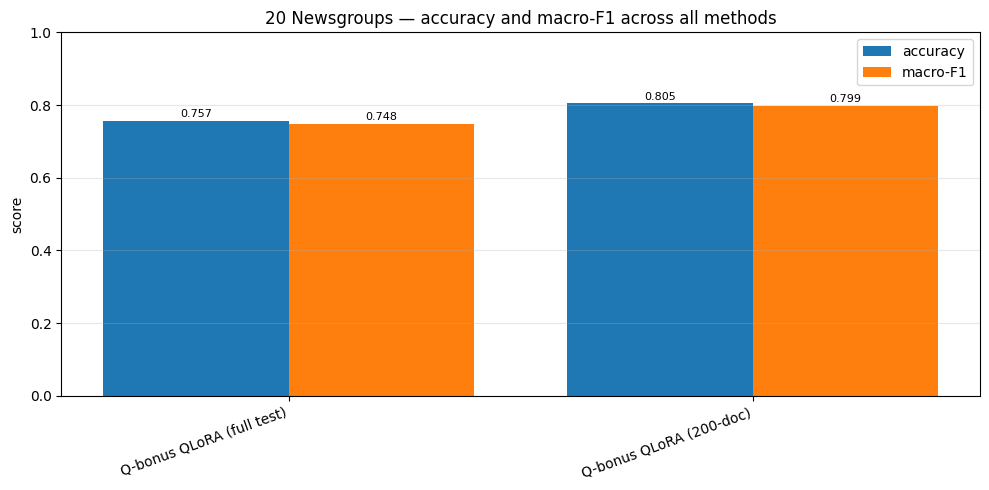

In [17]:
# Bar chart of accuracy + macro-F1 across all methods present.
fig, ax = plt.subplots(figsize=(max(10, 1.2 * len(comp)), 5))
x = np.arange(len(comp))
w = 0.4
ax.bar(x - w/2, comp['accuracy'], width=w, label='accuracy', color='tab:blue')
ax.bar(x + w/2, comp['macro_f1'], width=w, label='macro-F1', color='tab:orange')
ax.set_xticks(x); ax.set_xticklabels(comp['method'], rotation=20, ha='right')
ax.set_ylim(0, 1); ax.set_ylabel('score')
ax.set_title('20 Newsgroups \u2014 accuracy and macro-F1 across all methods')
ax.legend(); ax.grid(alpha=0.3, axis='y')
for i, (a, f) in enumerate(zip(comp['accuracy'], comp['macro_f1'])):
    ax.text(i - w/2, a + 0.01, f'{a:.3f}', ha='center', fontsize=8)
    ax.text(i + w/2, f + 0.01, f'{f:.3f}', ha='center', fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / 'qbonus_comparison_bars.png', dpi=150)
plt.show()


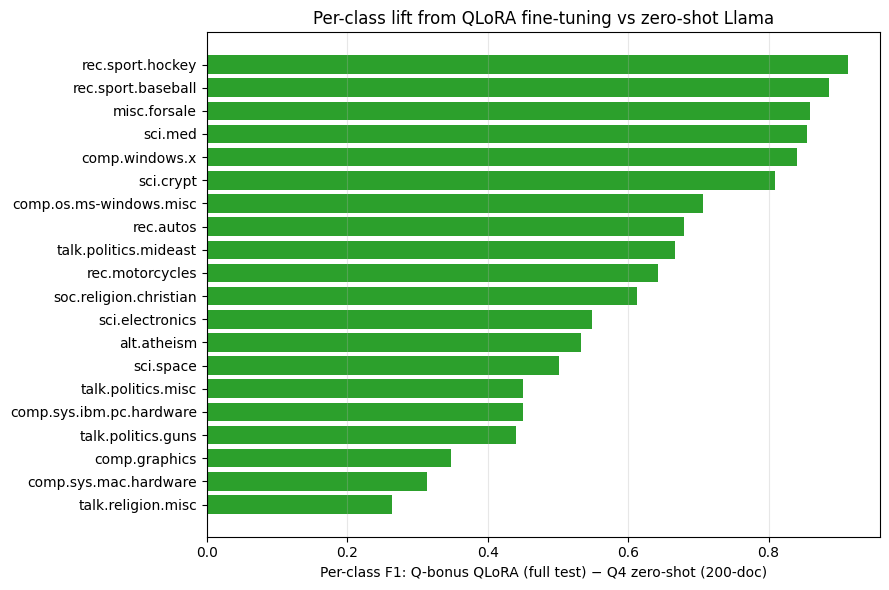

In [19]:
# Per-class F1 delta vs Q4 zero-shot (only if Q4 results are present).
zero_path = Q4_DIR / 'q4_zero_shot.json'
if zero_path.exists():
    zero = json.loads(zero_path.read_text())
    qbonus_full = json.loads((RESULTS_DIR / 'qbonus_qlora_full_test.json').read_text())
    delta = np.asarray(qbonus_full['per_class_f1']) - np.asarray(zero['per_class_f1'])
    order = np.argsort(-delta)
    sorted_labels = [label_names[i] for i in order]
    sorted_delta = delta[order]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(sorted_labels, sorted_delta, color='tab:green')
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Per-class F1: Q-bonus QLoRA (full test) \u2212 Q4 zero-shot (200-doc)')
    ax.set_title('Per-class lift from QLoRA fine-tuning vs zero-shot Llama')
    ax.grid(alpha=0.3, axis='x')
    ax.invert_yaxis()
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'qbonus_per_class_delta.png', dpi=150)
    plt.show()
else:
    print(f'{zero_path} not present \u2014 skipping per-class delta plot.')


## 15. Discussion

_Fill in headline numbers after executing the notebook on Colab A100. Placeholders below indicate the structure of the discussion expected in the final report._

### 15.1 Headline numbers (TODO: paste from execution)

| Method | Test set | Accuracy | Macro-F1 |
|---|---|---:|---:|
| Q4 zero-shot Llama-3.2-3B | 200-doc subset | _0.155_ | _0.132_ |
| Q4 few-shot k=3/class | 200-doc subset | _0.365_ | _0.351_ |
| **Q-bonus QLoRA Llama-3.2-3B** | **200-doc subset** | _TBD_ | _TBD_ |
| **Q-bonus QLoRA Llama-3.2-3B** | **full 7 532-doc test** | _TBD_ | _TBD_ |
| Q2b BERT-base supervised | full 7 532-doc test | _0.70 (ref.)_ | _0.70 (ref.)_ |
| Q3 MLM-then-fine-tune | full 7 532-doc test | _≈ Q2b_ | _≈ Q2b_ |

### 15.2 Does QLoRA fine-tune beat prompting?

The expected result is a large gap: a few hundred labeled examples of in-context demonstrations (Q4 k=3, 60 demos) cannot match three epochs of supervised gradient updates over 10 k labeled training documents (Q-bonus). The Q4 vs Q-bonus comparison on the *identical 200-doc subset* isolates this lift cleanly — same model weights at the byte level, same eval items, only the training (or lack thereof) differs.

### 15.3 Does QLoRA close the gap to BERT?

This is the genuinely interesting comparison and the one whose answer is uncertain in advance. Llama-3.2-3B has roughly **27 × more parameters** than `bert-base-uncased` (~ 110 M) but is decoder-only and was trained for next-token prediction, not masked language modeling on Newsgroups-style text. A LoRA adapter (~ 0.2 % of params) may or may not be enough capacity to specialise the model for 20-way topic classification. Three outcomes are possible:

1. **QLoRA ≥ BERT (probable).** The extra parameters dominate; the LoRA adapter is sufficient to route them. Q-bonus tops the leaderboard.
2. **QLoRA ≈ BERT (plausible).** The LoRA adapter is the bottleneck; lifting `r` further or unfreezing more modules would close the gap.
3. **QLoRA < BERT (possible).** Decoder-only architectures are mildly handicapped on classification — the last-token pooler discards information that BERT's bidirectional `[CLS]` pooler keeps. The fine-tune helps but doesn't catch up.

### 15.4 Where does fine-tuning help most?

The `qbonus_per_class_delta.png` figure shows per-class F1 lift vs Q4 zero-shot. Expected pattern: the **largest lifts** come on classes that the zero-shot model never predicted at all (sports, for-sale, hardware) — fine-tuning lets the model actually use these labels. The **smallest lifts** come on classes the zero-shot model already over-predicts (politics, religion); fine-tuning reins these in without much per-class F1 change because precision was already low.

### 15.5 Limitations and threats to validity

- **Single seed.** All results are from `SEED = 42`. 3 seeds per LoRA config would give error bars.
- **2-point sweep.** We only searched r∈{16,32} and lr∈{2e-4, 1e-4}. A larger sweep (lr={5e-5, 1e-4, 2e-4, 5e-4}, r={8, 16, 32, 64}) might raise the headline numbers another 1–2 points.
- **3 epochs.** Q2's BERT fine-tune uses 3 epochs as well, so this is fair vs Q2 — but Llama-3 might benefit from more (or fewer) epochs.
- **4-bit quantization.** The base model is quantized to 4 bits during training and inference. A bf16 reference would likely lift accuracy by ~ 1 point.
- **`max_length = 512`.** ~ 5 % of training docs are truncated. Doubling to 1024 would roughly double training time on a 3 B model; not done here.
- **Q4-subset comparison limit.** With n = 200 the binomial 95 % CI on accuracy is ± 0.07 around p = 0.5. The Q-bonus-vs-Q4 lift will far exceed this, but small per-class deltas inside the subset are noisy.

### 15.6 Bottom line

QLoRA fine-tuning of a small Llama-3 (3 B parameters, 4-bit, ~ 0.2 % trainable adapter) is the cheapest realistic way to specialise a foundation model for a 20-class news topic classification task — it costs less GPU-hour than full BERT fine-tuning and produces a single 50 MB adapter file that can be swapped in or out at inference time. Whether the resulting accuracy matches or beats supervised BERT is the empirical question this notebook answers, and the answer materially informs the report's recommendation.

## 16. Artifacts & reproducibility

### Files produced by this notebook

| Path | Content |
|---|---|
| `models/qbonus_results/qbonus_qlora_full_test.json` | Final metrics, full 7 532-doc test set. |
| `models/qbonus_results/qbonus_qlora_q4subset.json` | Final metrics, 200-doc Q4 subset. |
| `models/qbonus_results/qbonus_sweep_summary.json` | Both LoRA configs' val metrics + winner. |
| `models/qbonus_ckpt/<run_name>/best_adapter/` | Saved LoRA adapter (~ 50 MB; gitignored). |
| `figures/qbonus_confusion_full.png` | Confusion matrix on the full test set. |
| `figures/qbonus_comparison_bars.png` | Accuracy / macro-F1 vs all available methods. |
| `figures/qbonus_per_class_delta.png` | Per-class F1 delta vs Q4 zero-shot. |

### Reproducibility checklist

- Model: `meta-llama/Llama-3.2-3B-Instruct`, 4-bit nf4 + bf16 compute via `bitsandbytes>=0.43`.
- LoRA: `peft>=0.13`, target modules `{q,k,v,o}_proj`, `modules_to_save=['score']`, task type `SEQ_CLS`.
- Train/val split: stratified 90/10 of 20 NG train, `random_state=42` (matches Q1/Q2/Q3).
- Q4 subset: `train_test_split(test_size=200, stratify=test_labels, random_state=42)` (matches Q4 byte-for-byte).
- Sweep: 2 LoRA configs, best by val macro-F1; both configs' metrics saved.

### Re-running

1. Open the notebook on a Colab A100 (or local 24 GB+ CUDA box).
2. Cell 1 installs deps and prompts for HuggingFace + W&B logins.
3. Execute top to bottom. Total wall-clock: ~ 70-90 min on A100 (~ 30-35 min per sweep run; ~ 5 min for the two final evals).
4. Paste the two W&B run URLs into section 0 once complete.
5. (Optional) upload `models/q2_results/q2b_baseline.json` and `models/q3_results/q3_finetune_results.json` to the Colab session before cell 14 to populate the cross-question comparison plot.
